# Notebook 03: Classification Model

**Student Name:** [Kyle Grover]

**Dataset:** [Student Performance Factors]

**Original Target Variable:** [Exam_Score]

**Binned Target Variable:** [High Achieving]

**Checkpoint 4 Due:** Feb 22

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Your binning justification, model selection reasoning, and analysis of the confusion matrix demonstrate your understanding. These reflections are what employers look for—the ability to communicate technical decisions clearly.

---

## Setup

In [180]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [181]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (6607, 25)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Total_Study_Time,Study_Efficiency,Study_Efficiency_Numbers,Parental_Teacher_Influence,Access_to_Resources_Numeric
0,23,84,Low,High,No,7,73,Low,Yes,0.0,...,No,High School,Near,Male,67,0.0,0.041667,1,1,2
1,19,64,Low,Medium,No,8,59,Low,Yes,2.0,...,No,College,Moderate,Female,61,38.0,0.050000,1,2,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2.0,...,No,Postgraduate,Near,Male,74,48.0,0.080000,2,3,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1.0,...,No,High School,Moderate,Male,71,29.0,0.066667,2,1,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3.0,...,No,College,Near,Female,70,57.0,0.100000,2,2,1


In [182]:
# Define your original target variable
ORIGINAL_TARGET = 'Exam_Score'  # <-- UPDATE THIS

print(f"Original Target: {ORIGINAL_TARGET}")
print(f"\nTarget statistics:")
print(df[ORIGINAL_TARGET].describe())

Original Target: Exam_Score

Target statistics:
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


## Section 2: Create Binned Target

Convert your regression target into classification categories.

### 2.1 Binning Strategy Justification

**Your approved binning strategy:**

- **Number of categories:** [e.g., 4]
- **Category names:** [needs support, Average, Above Average, High Achieving]
- **Thresholds:** [65,67,70]

**Why this makes sense for your problem:**

[SO the reason why the first binning threshold is 65 is this is the main standard for grading when it comes to a passing grade, while 67 and 70 are the difference between a C and B because you want to differentiate between those who are just trying to get by and those who are actually working hard for their grade. ]

In [183]:
# View the distribution before binning
print("Target distribution:")
print(f"Min: {df[ORIGINAL_TARGET].min():.2f}")
print(f"25th percentile: {df[ORIGINAL_TARGET].quantile(0.25):.2f}")
print(f"Median: {df[ORIGINAL_TARGET].median():.2f}")
print(f"75th percentile: {df[ORIGINAL_TARGET].quantile(0.75):.2f}")
print(f"Max: {df[ORIGINAL_TARGET].max():.2f}")

Target distribution:
Min: 55.00
25th percentile: 65.00
Median: 67.00
75th percentile: 69.00
Max: 101.00


In [184]:
# TODO: Create your binned target using YOUR approved binning strategy
#
# Steps:
# 1. Define your bin edges (e.g., bins = [min-1, threshold1, threshold2, max+1])
# 2. Define your category labels (e.g., labels = ['Low', 'Medium', 'High'])
# 3. Use pd.cut() to create the binned column
#
# Example:
# bins = [df[ORIGINAL_TARGET].min()-1, 50000, 100000, df[ORIGINAL_TARGET].max()+1]
# labels = ['Low', 'Medium', 'High']
# df['target_category'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)

# YOUR CODE HERE:
bins = [df[ORIGINAL_TARGET].min() - 1, 65, 67, 70, df[ORIGINAL_TARGET].max() + 1]
labels = ['Needs Support', 'Average', 'Above Average', 'High Achiever']

df['Exam_Score'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)

print("Binned target distribution:")
print(df['Exam_Score'].value_counts())

Binned target distribution:
Exam_Score
Needs Support    2131
Above Average    1925
Average          1468
High Achiever    1083
Name: count, dtype: int64


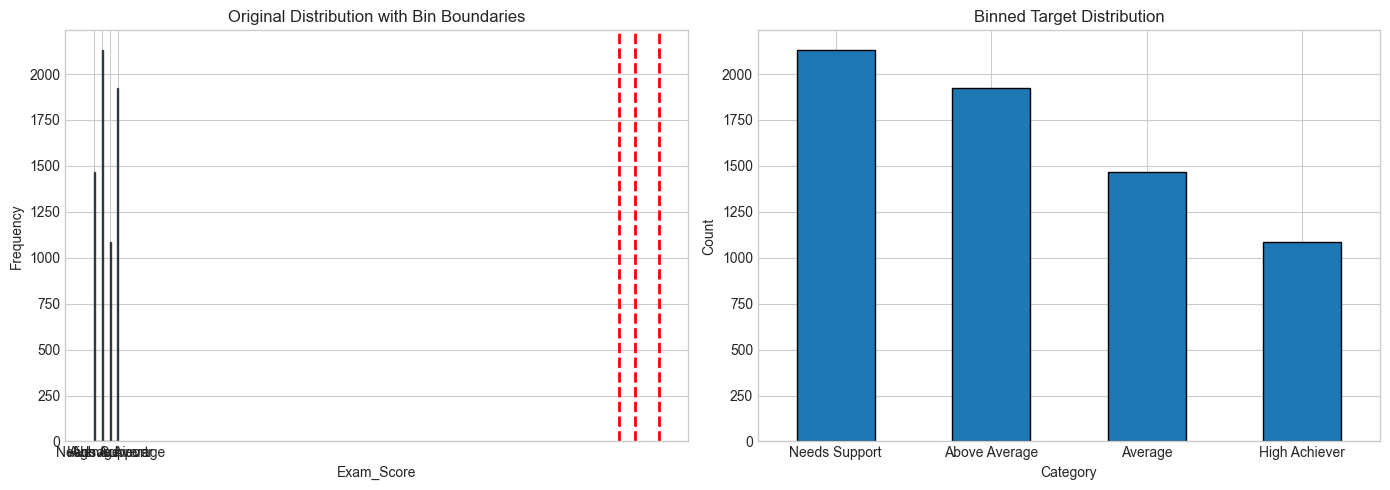

In [185]:
# Visualize the binned distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution with bin lines
axes[0].hist(df[ORIGINAL_TARGET], bins=30, edgecolor='black', alpha=0.7)
for edge in bins[1:-1]:  # Skip first and last (min/max)
    axes[0].axvline(edge, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel(ORIGINAL_TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution with Bin Boundaries')

# Binned category counts
df['Exam_Score'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Binned Target Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2.2 Check Class Balance

*Is your binned target reasonably balanced?*

In [186]:
# Check class balance
class_counts = df['Exam_Score'].value_counts()
class_percentages = df['Exam_Score'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
Needs Support: 2131 (32.3%)
Above Average: 1925 (29.1%)
Average: 1468 (22.2%)
High Achiever: 1083 (16.4%)

Class balance looks reasonable!


## Section 3: Feature Consistency Check

**Important:** For consistency, you should use the same features for classification as you did for regression. This makes your app simpler (users enter the same inputs for both models) and allows for fair comparison.

If you decide to use different features, provide a strong justification below.

In [187]:
# Load the features you selected in the regression notebook
try:
    regression_features = joblib.load('../models/regression_features.pkl')
    print("Features from Regression Model:")
    print(regression_features)
    print(f"\nNumber of regression features: {len(regression_features)}")
except FileNotFoundError:
    print("Warning: regression_features.pkl not found!")
    print("Make sure you've completed Notebook 02 and saved your regression model first.")
    regression_features = None

Features from Regression Model:
['Attendance', 'Hours_Studied', 'Total_Study_Time', 'Previous_Scores']

Number of regression features: 4


### Feature Selection Decision

**Will you use the same features as your regression model?**

- [X] **Yes, same features** (Recommended for simpler deployment)
- [ ] **No, different features** (Requires justification below)

**If using different features, justify why:**



In [188]:
# DECIDE: Use regression features or define new ones?

# Option A: Use the same features as regression (RECOMMENDED)
if regression_features is not None:
    SELECTED_FEATURES = regression_features
    print("Using same features as regression model.")
    # Option B: Define your own features (if regression not done yet)

    print("Defining features manually.")

print(f"\nSelected features for classification ({len(SELECTED_FEATURES)}):")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i}. {f}")

Using same features as regression model.
Defining features manually.

Selected features for classification (4):
  1. Attendance
  2. Hours_Studied
  3. Total_Study_Time
  4. Previous_Scores


## Section 4: Prepare Features and Target

In [189]:
# Create feature matrix using SELECTED features
X = df[SELECTED_FEATURES].copy()
y = df['Exam_Score']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (6607, 4)
Target shape: (6607,)

Features used: ['Attendance', 'Hours_Studied', 'Total_Study_Time', 'Previous_Scores']

Target classes: ['Average', 'Needs Support', 'High Achiever', 'Above Average']


### 4.1 Label Encoding

Many sklearn models require numeric targets. Use LabelEncoder to convert category names to numbers.

In [190]:
# TODO: Encode your target labels to numbers using LabelEncoder
#
# Steps:
# 1. Create a LabelEncoder instance
# 2. Fit and transform y to create y_encoded
#
# Hint: label_encoder.fit_transform(y)

# YOUR CODE HERE:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Encoded target classes: {label_encoder.classes_}")
print(f"Encoded target distribution:")
print(pd.Series(y_encoded).value_counts())


Encoded target classes: ['Above Average' 'Average' 'High Achiever' 'Needs Support']
Encoded target distribution:
3    2131
0    1925
1    1468
2    1083
Name: count, dtype: int64


In [153]:
# Verify encoding (run this to check)
print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label encoding:
Above Average -> 0
Average -> 1
High Achiever -> 2
Needs Support -> 3


## Section 5: Train-Test Split

For classification, we use **stratified** splitting to ensure each class is proportionally represented in both train and test sets.

In [191]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2)
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test

# YOUR CODE HERE:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")



Training set shape: (5285, 4), (5285,)
Test set shape: (1322, 4), (1322,)


In [192]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)")

Training set: 5285 samples
Test set: 1322 samples

Training class distribution:
  Above Average: 1540 (29.1%)
  Average: 1174 (22.2%)
  High Achiever: 866 (16.4%)
  Needs Support: 1705 (32.3%)


## Section 6: Feature Scaling

In [193]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
# 2. fit_transform on X_train
# 3. transform (only!) on X_test
#
# Store in: X_train_scaled, X_test_scaled

# YOUR CODE HERE:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")



Feature scaling complete.
X_train_scaled shape: (5285, 4)
X_test_scaled shape: (1322, 4)


In [194]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 4 features.


## Section 7: Baseline Model

In [195]:
# This helper function evaluates any classifier - you'll use it throughout
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Train classifier and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision (weighted)': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_test, y_test_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results, model, y_test_pred

In [196]:
# TODO: Create and evaluate a baseline Logistic Regression model
#
# Create LogisticRegression(random_state=42, max_iter=1000)
# Use evaluate_classifier() to train and evaluate

# YOUR CODE HERE:
# baseline_model = ...
# baseline_results, baseline_trained, baseline_preds = evaluate_classifier(...)
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_results, baseline_trained, baseline_preds = evaluate_classifier(
    baseline_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression (Baseline)"
)
print("\nBaseline Model Evaluation:")

for metric, value in baseline_results.items():
    if metric != 'Model':
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")



Baseline Model Evaluation:
Model: Logistic Regression (Baseline)
Train Accuracy: 0.6696
Test Accuracy: 0.6611
Precision (weighted): 0.6592
Recall (weighted): 0.6611
F1 (weighted): 0.6588


In [197]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Logistic Regression")
print("=" * 50)
print(f"Train Accuracy: {baseline_results['Train Accuracy']:.4f}")
print(f"Test Accuracy:  {baseline_results['Test Accuracy']:.4f}")
print(f"F1 Score:       {baseline_results['F1 (weighted)']:.4f}")

BASELINE MODEL: Logistic Regression
Train Accuracy: 0.6696
Test Accuracy:  0.6611
F1 Score:       0.6588


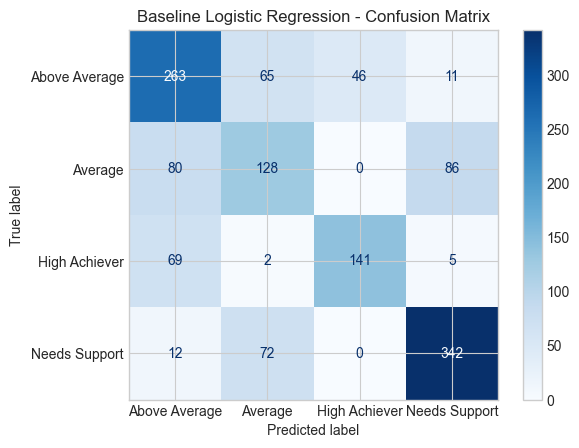

In [198]:
# TODO: Create and display the confusion matrix for baseline
#
# Steps:
# 1. Use confusion_matrix(y_test, baseline_preds) to create the matrix
# 2. Use ConfusionMatrixDisplay to visualize it
#
# Hint: ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# YOUR CODE HERE:
cm = confusion_matrix(y_test, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()



### Understanding the Confusion Matrix

The confusion matrix shows where your model gets predictions right and wrong:

- **Diagonal cells (top-left to bottom-right):** Correct predictions
- **Off-diagonal cells:** Misclassifications
- **Row:** What the actual class was
- **Column:** What the model predicted

**How to read it:** 
- If a row has many values spread across columns, that class is often confused with others
- If a column has many values from different rows, the model is predicting that class too often

**Example interpretation:**
- "20 Low samples were correctly predicted as Low"
- "5 Medium samples were incorrectly predicted as High"

### Baseline Interpretation

*Analyze your baseline results:*

**Questions to answer:**
- How well does the baseline perform?
- Which classes are easiest/hardest to predict (look at the diagonal)?
- Where does the model get confused (look at off-diagonal cells)?
- Is there overfitting (train vs test accuracy gap)?

**Your interpretation:**

[To start there is no overfitting happening here. The model most easily predicts the above average and needs support students while the over achievers and average is the harder of the 4 to predict. Where the model gets confused is where the average and the over achievers meet, there seems to be some confusion there and thats probably due to the binning strategy I used instead of using a simple grading scale.]

## Section 8: Cross-Validation

Cross-validation gives us a more robust estimate of model performance by training on different portions of the data.

In [199]:
# Cross-validation for key models
print("5-Fold Cross-Validation Results")
print("=" * 50)

models_to_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

cv_results = []
for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
cv_df

5-Fold Cross-Validation Results
Logistic Regression: 0.6655 (+/- 0.0292)
Random Forest: 0.6327 (+/- 0.0153)
Gradient Boosting: 0.6269 (+/- 0.0082)


,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.665468,0.014578
1,Random Forest,0.632734,0.007649
2,Gradient Boosting,0.626868,0.004085


### Cross-Validation Interpretation

*What does the cross-validation tell you?*

- Which model is most consistent (lowest std)?
- Does the ranking change from the single train/test split?

**Your interpretation:**

[The most consistent model is gradient boosting with (0.004085) however the cross-validation shows that Logistic Regression is the best overall model. Even after testing it on multiple different subsets of data. First thing is that the student data is pretty straight forward and doesn't require the complexity of decision trees and although the Gradient boosting is more stable and predictable model it doesn't match the accuracy of the linear regression model.]

## Section 9: Model Iteration

In [163]:
# Store all results
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Logistic Regression (Baseline)': baseline_trained
}

### Model 2: Decision Tree

In [164]:
# TODO: Create and evaluate a Decision Tree classifier
#
# Create DecisionTreeClassifier(max_depth=10, random_state=42)
# Use evaluate_classifier() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_results, dt_trained, dt_preds = evaluate_classifier(
    dt_model, X_train_scaled, X_test_scaled, y_train, y_test, "Decision Tree (max_depth=10)")
all_results.append(dt_results)
trained_models['Decision Tree (max_depth=10)'] = dt_trained


# Print results
print(f"Decision Tree - Test Accuracy: {dt_results['Test Accuracy']:.4f}, F1: {dt_results['F1 (weighted)']:.4f}")

Decision Tree - Test Accuracy: 0.5923, F1: 0.5927


### Model 3: Random Forest

In [165]:
# TODO: Create and evaluate a Random Forest classifier
#
# Create RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_results, rf_trained, rf_preds = evaluate_classifier(
    rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest (n_estimators=100, max_depth=10)")
all_results.append(rf_results)
trained_models['Random Forest (n_estimators=100, max_depth=10)'] = rf_trained



# Print results
print(f"Random Forest - Test Accuracy: {rf_results['Test Accuracy']:.4f}, F1: {rf_results['F1 (weighted)']:.4f}")

Random Forest - Test Accuracy: 0.6475, F1: 0.6438


### Model 4: K-Nearest Neighbors

In [166]:
# TODO: Create and evaluate a KNN classifier
#
# Create KNeighborsClassifier(n_neighbors=5)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results, knn_trained, knn_preds = evaluate_classifier(
    knn_model, X_train_scaled, X_test_scaled, y_train, y_test,
    "KNN (n_neighbors=5)")
all_results.append(knn_results)
trained_models['KNN (n_neighbors=5)'] = knn_trained

# Print results
print(f"KNN - Test Accuracy: {knn_results['Test Accuracy']:.4f}, F1: {knn_results['F1 (weighted)']:.4f}")

KNN - Test Accuracy: 0.6089, F1: 0.6091


### Model 5: Gradient Boosting

In [167]:
# TODO: Create and evaluate a Gradient Boosting classifier
#
# Create GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_results, gb_trained, gb_preds = evaluate_classifier(
    gb_model, X_train_scaled, X_test_scaled, y_train, y_test,
    "Gradient Boosting (n_estimators=100, max_depth=5)")
all_results.append(gb_results)
trained_models['Gradient Boosting (n_estimators=100, max_depth=5)'] = gb_trained


# Print results
print(f"Gradient Boosting - Test Accuracy: {gb_results['Test Accuracy']:.4f}, F1: {gb_results['F1 (weighted)']:.4f}")

Gradient Boosting - Test Accuracy: 0.6377, F1: 0.6358


### Add Your Own Model (Optional)

Try a different model or different hyperparameters!

In [168]:
# YOUR ADDITIONAL MODEL HERE:
# Try SVC, different hyperparameters, or another classifier


svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_results, svc_trained, svc_preds = evaluate_classifier(
    svc_model, X_train_scaled, X_test_scaled, y_train, y_test,
    "SVC (kernel='rbf', C=1.0)")
all_results.append(svc_results)
trained_models['SVC (kernel=\'rbf\', C=1.0)'] = svc_trained

# Print results
print(f"SVC - Test Accuracy: {svc_results['Test Accuracy']:.4f}, F1: {svc_results['F1 (weighted)']:.4f}")

SVC - Test Accuracy: 0.6747, F1: 0.6713


## Section 10: Model Comparison

In [169]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train Accuracy,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
5,"SVC (kernel='rbf', C=1.0)",0.6721,0.6747,0.6749,0.6747,0.6713
0,Logistic Regression (Baseline),0.6696,0.6611,0.6592,0.6611,0.6588
2,"Random Forest (n_estimators=100, max_depth=10)",0.8377,0.6475,0.6435,0.6475,0.6438
4,"Gradient Boosting (n_estimators=100, max_depth=5)",0.8102,0.6377,0.6355,0.6377,0.6358
3,KNN (n_neighbors=5),0.7279,0.6089,0.6123,0.6089,0.6091
1,Decision Tree (max_depth=10),0.7845,0.5923,0.5998,0.5923,0.5927


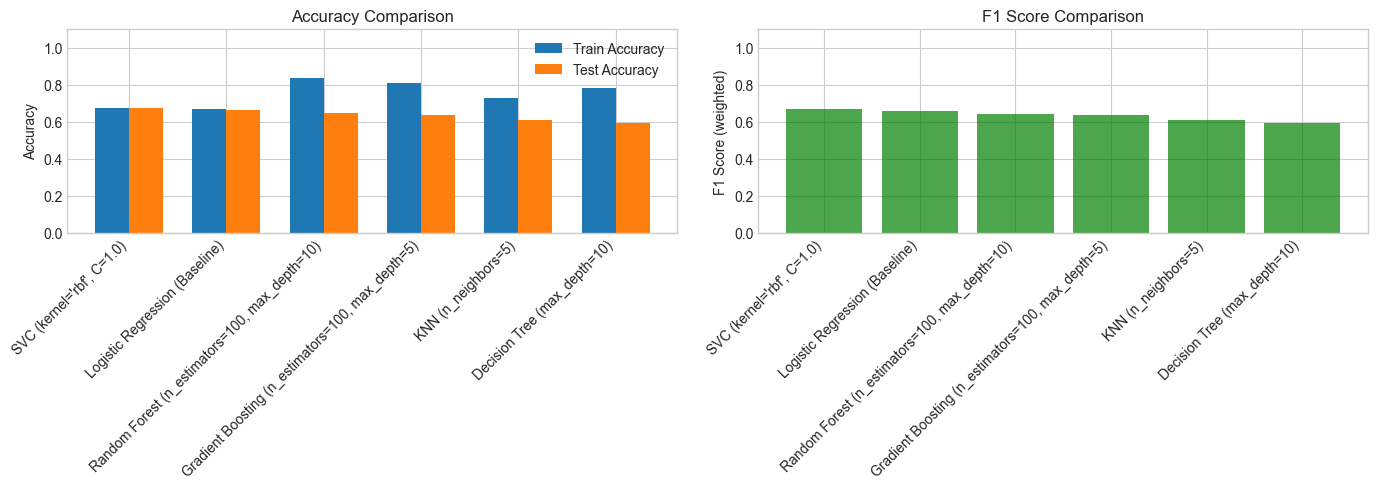

In [170]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy')
axes[0].bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# F1 Score comparison
axes[1].bar(x, results_df['F1 (weighted)'], color='green', alpha=0.7)
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## Section 11: Best Model Selection

In [171]:
# Identify best model (by test accuracy)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['F1 (weighted)']:.4f}")

Best Model: SVC (kernel='rbf', C=1.0)
Test Accuracy: 0.6747
F1 Score: 0.6713


### Best Model Justification

I chose the SVC because it achieved the highest test accuracy (0.6747) and F1-score (0.6713) by finding the most effective boundaries between student categories

**Questions to consider:**
- Why this model over others?
- Is there significant overfitting? 
- How does it compare to baseline?
- Which metrics did you prioritize and why?

**Your justification:**

[There was not Overfitting in the model due to the model having nearly identical scores in the test and training data. Although until this point the linear regression model has done the best, the SVC does better because its able to pick up more complex patterns then a simple linear relationship. I prioritized the Weighted F1-Score to ensure the model accurately predicts every student group, even though some categories (like "Needs Support") have many more students than others.]

## Section 12: Best Model Analysis

In [172]:
# Get predictions from best model
y_pred = best_model.predict(X_test_scaled)

# Detailed classification report
print("Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
               precision    recall  f1-score   support

Above Average       0.62      0.72      0.67       385
      Average       0.52      0.45      0.49       294
High Achiever       0.78      0.61      0.69       217
Needs Support       0.78      0.82      0.80       426

     accuracy                           0.67      1322
    macro avg       0.67      0.65      0.66      1322
 weighted avg       0.67      0.67      0.67      1322



### Understanding the Classification Report

The classification report shows per-class metrics:

- **Precision:** Of all predictions for this class, what % were correct?
  - High precision = Few false positives
  - Example: "When the model predicts 'High', it's correct 85% of the time"

- **Recall:** Of all actual instances of this class, what % did we find?
  - High recall = Few false negatives
  - Example: "We correctly identified 90% of all actual 'High' cases"

- **F1-Score:** Harmonic mean of precision and recall (balanced measure)
  - Good when you need both precision and recall

- **Support:** Number of actual occurrences of each class in the test set

<Figure size 800x600 with 0 Axes>

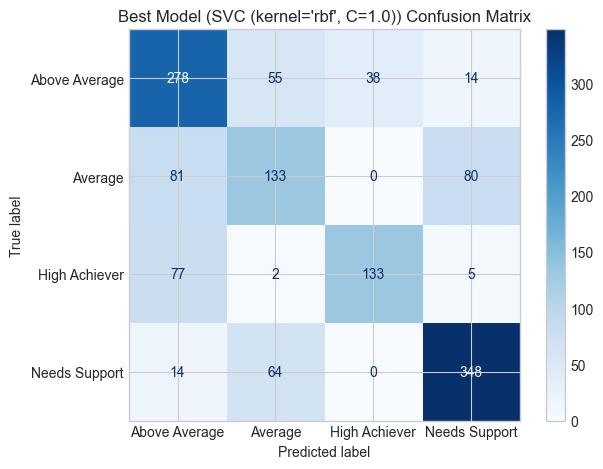

In [173]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title(f'Best Model ({best_model_name}) Confusion Matrix')
plt.tight_layout()
plt.show()

### Detailed Confusion Matrix Analysis

*Analyze the confusion matrix carefully:*

**For each class, describe:**
1. How many correct predictions (diagonal)?
2. What are the most common misclassifications?
3. Does the confusion make sense for your problem?

**Your analysis:**

[WThe model most often confuses the middle tiered students and being able to separate them efficiently into where the students need to be, which again could be the result of the binning strategy used. The confusion matrix confirms the model is highly reliable for identifying the students who need support and those who are high achievers. ]

In [174]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 most important features:")
    for i, row in importance.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
        
elif hasattr(best_model, 'coef_'):
    # For multi-class, coef_ has shape (n_classes, n_features)
    coef = best_model.coef_
    if len(coef.shape) > 1:
        # Average absolute importance across classes
        importance_vals = np.abs(coef).mean(axis=0)
    else:
        importance_vals = np.abs(coef)
    
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance_vals
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Average Absolute Coefficient')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()

## Section 13: Model Iteration Reflection

*Reflect on your modeling process:*

**1. How did your models evolve from baseline to best?**

[I started with a Logistic Regression baseline that worked surprisingly well, showing that student performance follows a clear linear trend. I tried complex models like Random Forest, but they overfitted the data, so I ultimately chose the SVC because it captured complex patterns without losing accuracy on new data.]

**2. What surprised you about the results?**

[I was surprised that the most complex models, like Random Forest, performed the worst on the test set despite having the highest training scores. It was also unexpected that the SVC was able to beat all other models so easily, proving that "more complex" isn't always "better." the old saying still holds true sometimes less is more.]

**3. If you had more time, what would you try next?**

[I would have tried the straight line grading system strategy to see what the results would be at the end, I think many of the issues I ran into with this project was just simply due to the binning strategy that I chose.]

## Section 14: Save Model and Artifacts

In [175]:
# Save the best classification model
model_path = '../models/classification_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on SELECTED features)
scaler_path = '../models/classification_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save the label encoder
encoder_path = '../models/label_encoder.pkl'
joblib.dump(label_encoder, encoder_path)
print(f"Label encoder saved to {encoder_path}")

# Save feature names (SELECTED_FEATURES)
features_path = '../models/classification_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

# Save binning info (for reference in Streamlit app)
binning_info = {
    'bins': bins,
    'labels': labels,
    'original_target': ORIGINAL_TARGET
}
binning_path = '../models/binning_info.pkl'
joblib.dump(binning_info, binning_path)
print(f"Binning info saved to {binning_path}")

Model saved to ../models/classification_model.pkl
Scaler saved to ../models/classification_scaler.pkl
Label encoder saved to ../models/label_encoder.pkl
Features saved to ../models/classification_features.pkl
Binning info saved to ../models/binning_info.pkl


In [178]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_encoder = joblib.load(encoder_path)

# Test prediction
test_sample = X_test.iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)
test_pred_label = loaded_encoder.inverse_transform(test_pred)

print(f"\nModel verification:")
print(f"Sample input: {test_sample.values[0][:3]}...")
print(f"Predicted class: {test_pred_label[0]}")
#print(f"Actual class: {loaded_encoder.inverse_transform([y_test.iloc[0]])[0]}")
print(f"Actual class: {loaded_encoder.inverse_transform([y_test[0]])[0]}")
print("\nModel saved and verified successfully!")


Model verification:
Sample input: [87.  9.  9.]...
Predicted class: Needs Support
Actual class: Needs Support

Model saved and verified successfully!


---

## Summary

### What You Accomplished
- [X] Created binned target variable with justification
- [X] Verified class balance
- [X] Used consistent features (same as regression or justified different)
- [X] Split data with stratification
- [X] Performed cross-validation
- [X] Built baseline classifier
- [X] Tried multiple classifier types
- [X]] Compared and selected best model
- [X] Analyzed model with confusion matrix and classification report
- [X] Saved model, scaler, encoder, and binning info

### Key Results

**Best Model:** [SVC model]

**Test Accuracy:** [67.47%]

**F1 Score:** [67.13% (Weighted)]

**Improvement over baseline:** [he SVC achieved a roughly 1.4% increase in accuracy over the Logistic Regression baseline (66.11%) while maintaining much better stability than the overfitted tree-based models.]

### Comparison to Regression

*How does classification performance relate to your regression results?*

[Predicting categories is more practical because it groups students into useful academic tiers instead of trying to hit an exact number, you would rather students who may not need the help get the extra support so they can improve then not get the support at all and barely scrape by. This makes small misses—like mistaking a 69 for a 71—less important, as both students are still recognized as being in a similar performance range.]

---

## Next Steps

Move on to building your **Streamlit app** to deploy both models!

You now have saved:
- `regression_model.pkl` and `regression_scaler.pkl`
- `classification_model.pkl`, `classification_scaler.pkl`, and `label_encoder.pkl`

The Streamlit starter code in `app/app.py` will load these files.

---

## Checkpoint 4 Submission Instructions

You've completed the classification model. Time to submit!

### Step 1: Save and Close
Make sure this notebook is saved and all cells have been run.

### Step 2: Commit Your Work
```bash
git add .
git commit -m "Complete classification model - Checkpoint 4"
git push
```

### Step 3: Submit to Canvas
1. Go to Canvas
2. Find the **Checkpoint 4: Classification Model** assignment
3. Submit the link to your GitHub repository

### What Gets Graded
- Binning justification and implementation
- Feature consistency (same as regression or justified different)
- Model comparison and selection reasoning
- Confusion matrix interpretation
- Classification report analysis
- All written reflections completed

---